# Arrival model tuning charts (sketch)

Exploratory matplotlib sketches for six studio slider ↔ chart pairs on PR #78 (`worktree-T-163-corridor-mixture`).

Outputs: `notebooks/outputs/arrival_tuning_sketch/*.png` (gitignored).

**Data sources**
- **Rust / PyO3:** marginal arrival laws (`arrival_marginal_cdf_py`), `arrival_tuning_sketch_data` example (MC + traces).
- **Python:** Q10 φ(T) ladder (same formula as `voi_core::physics::store_temp_factor`).


In [1]:
from __future__ import annotations

import json
import subprocess
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

REPO = Path.cwd().resolve()
if not (REPO / "src" / "blueberries_voi").is_dir():
    REPO = REPO.parent
assert (REPO / "data" / "abdella" / "arrival_model.json").is_file(), REPO

FIG_DIR = REPO / "notebooks" / "outputs" / "arrival_tuning_sketch"
FIG_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACT = REPO / "data" / "abdella" / "arrival_model.json"
BASE_ARTIFACT = json.loads(ARTIFACT.read_text())

from blueberries_voi._core import arrival_marginal_cdf_py


def write_artifact(overrides: dict) -> str:
    art = {**BASE_ARTIFACT, **overrides}
    path = FIG_DIR / "_tmp_arrival_model.json"
    path.write_text(json.dumps(art))
    return str(path)


def cdf_to_pdf(cdf: np.ndarray, f: np.ndarray) -> np.ndarray:
    pdf = np.gradient(cdf, f)
    return np.clip(pdf, 0.0, None)


def marginal_pdf(condition: str, *, overrides: dict | None = None, n: int = 256) -> tuple[np.ndarray, np.ndarray, float]:
    src = write_artifact(overrides or {})
    f = np.linspace(0.0, 1.0, n)
    cdf = np.asarray(arrival_marginal_cdf_py(src, condition, f.tolist()), dtype=float)
    pdf = cdf_to_pdf(cdf, f)
    atom = float(cdf[0])
    return f, pdf, atom


def cargo_sketch_data() -> dict:
    cmd = [
        "cargo",
        "run",
        "-p",
        "voi_core",
        "--release",
        "--example",
        "arrival_tuning_sketch_data",
    ]
    t0 = time.perf_counter()
    proc = subprocess.run(cmd, cwd=REPO, capture_output=True, text=True, check=True)
    print(f"arrival_tuning_sketch_data: {time.perf_counter() - t0:.1f}s")
    return json.loads(proc.stdout)


SKETCH = cargo_sketch_data()


arrival_tuning_sketch_data: 135.5s


## Pair 1 — Preview transit days → P(f|d) vs Prior

Slider concept: `preview_transit_days` ∈ [2, 7] (studio preview of the F2 **Duration** channel).

Chart: unconditional **Prior** vs **Duration(d)** conditional arrival-f PDFs (filter laws on a uniform grid).


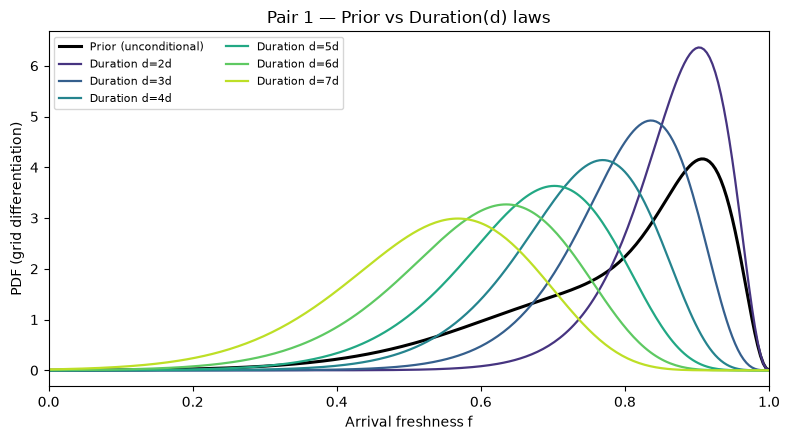

saved /home/oliver/blog/blueberries-voi/.worktrees/pr78-arrival-charts-sketch/notebooks/outputs/arrival_tuning_sketch/01_preview_transit_prior_vs_duration.png


In [2]:
fig, ax = plt.subplots(figsize=(8, 4.5))
preview_days = np.arange(2, 8)

f, pdf_prior, p0_prior = marginal_pdf("prior")
ax.plot(f, pdf_prior, color="black", lw=2.2, label="Prior (unconditional)")

colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(preview_days)))
for d, c in zip(preview_days, colors, strict=True):
    f_d, pdf_d, _ = marginal_pdf(f"duration:{d}")
    ax.plot(f_d, pdf_d, color=c, lw=1.6, label=f"Duration d={d}d")

ax.set_xlabel("Arrival freshness f")
ax.set_ylabel("PDF (grid differentiation)")
ax.set_title("Pair 1 — Prior vs Duration(d) laws")
ax.set_xlim(0, 1)
ax.legend(ncol=2, fontsize=8, loc="upper left")
fig.tight_layout()
p1 = FIG_DIR / "01_preview_transit_prior_vs_duration.png"
fig.savefig(p1, dpi=150)
plt.show()
print(f"saved {p1}")


## Pair 2 — Break hazard ρ → Var(log Λ) decomposition

Slider: `rho` ∈ [0, 0.15]. Stacked bars: **duration + thermal (ρ=0)** vs **incremental break** share of `Var(log Λ)` from Rust MC (`arrival_tuning_sketch_data`).

Dashed reference: `calibration_note.md` design target ~82% / ~18% at ρ=0.08 (scenario documentation; ADR 0150 retired the old 98% duration figure).


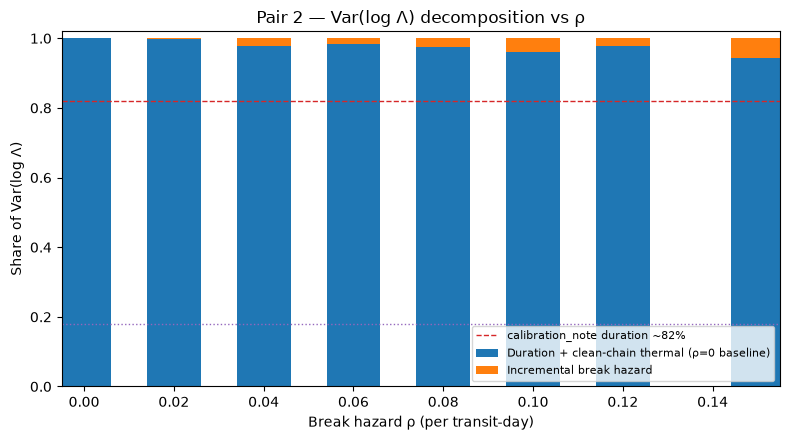

default rho=0.08 MC shares: [{'break_share': 0.0240849740948372, 'duration_share': 0.9759150259051628, 'rho': 0.08, 'var_log_lambda_clean': 0.18118414593199858, 'var_log_lambda_full': 0.1856556576367394}]


In [3]:
rows = sorted(SKETCH["var_log_decomposition"], key=lambda r: r["rho"])
rhos = [r["rho"] for r in rows]
dur = [r["duration_share"] for r in rows]
brk = [r["break_share"] for r in rows]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(rhos, dur, width=0.012, label="Duration + clean-chain thermal (ρ=0 baseline)")
ax.bar(rhos, brk, width=0.012, bottom=dur, label="Incremental break hazard")
ax.axhline(0.82, color="C3", ls="--", lw=1, label="calibration_note duration ~82%")
ax.axhline(0.18, color="C4", ls=":", lw=1)
ax.set_xlabel("Break hazard ρ (per transit-day)")
ax.set_ylabel("Share of Var(log Λ)")
ax.set_title("Pair 2 — Var(log Λ) decomposition vs ρ")
ax.set_xlim(-0.005, 0.155)
ax.set_ylim(0, 1.02)
ax.legend(fontsize=8)
fig.tight_layout()
p2 = FIG_DIR / "02_rho_var_log_lambda_decomposition.png"
fig.savefig(p2, dpi=150)
plt.show()
print(f"default rho=0.08 MC shares:", [r for r in rows if abs(r["rho"] - 0.08) < 1e-9])


## Pair 3 — Mean break duration τ̄ → synthetic break trace

Slider: `tau_bar` ∈ [0.1, 1.5] days. Chart: `truth_transit_trace` temperature path with break pulses (ρ=0.12 for visibility).


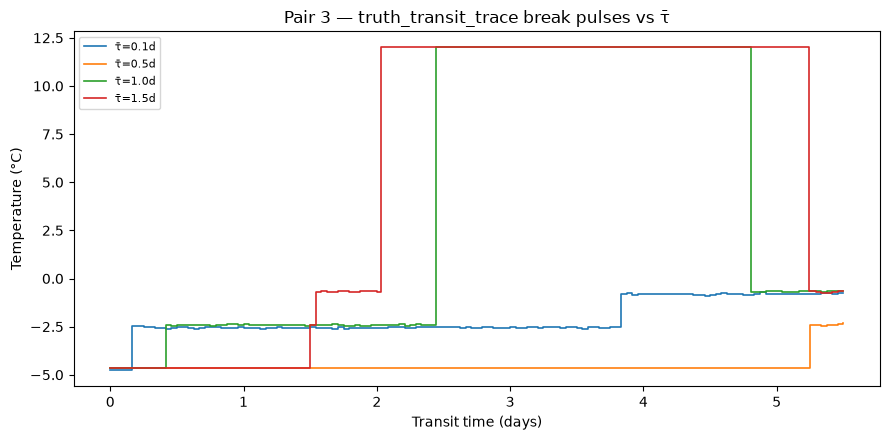

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for tr in SKETCH["tau_bar_traces"]:
    t = np.asarray(tr["times_d"], dtype=float)
    temp = np.asarray(tr["temps_c"], dtype=float)
    ax.plot(t, temp, lw=1.2, label=f"τ̄={tr['tau_bar']:.1f}d")

ax.set_xlabel("Transit time (days)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Pair 3 — truth_transit_trace break pulses vs τ̄")
ax.legend(fontsize=8)
fig.tight_layout()
p3 = FIG_DIR / "03_tau_bar_break_trace.png"
fig.savefig(p3, dpi=150)
plt.show()


## Pair 4 — Break temperature T_break → φ(T) ladder

Slider: `T_break` ∈ [8, 20] °C. Chart: Q10 φ(T) with φ_set (reefer baseline) and φ(T_break) markers.


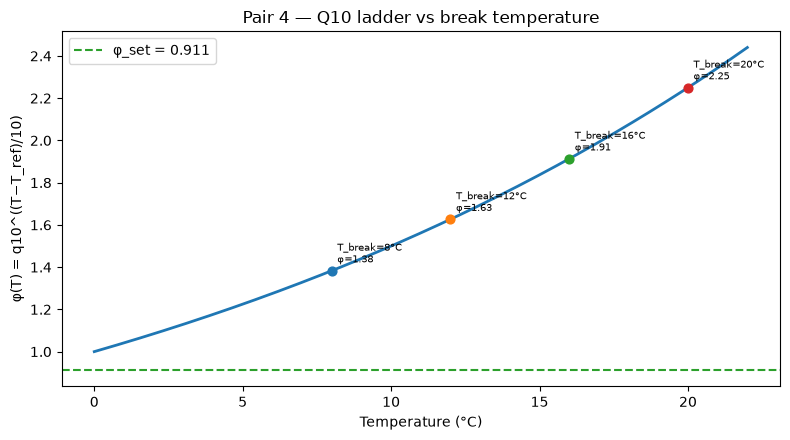

In [5]:
q10 = float(BASE_ARTIFACT["q10"])
t_ref = float(BASE_ARTIFACT["T_ref"])
phi_set = float(SKETCH["phi_set"])

T = np.linspace(0, 22, 200)
phi = q10 ** ((T - t_ref) / 10.0)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(T, phi, color="C0", lw=2)
ax.axhline(phi_set, color="C2", ls="--", label=f"φ_set = {phi_set:.3f}")

for t_break in [8.0, 12.0, 16.0, 20.0]:
    pb = q10 ** ((t_break - t_ref) / 10.0)
    ax.scatter([t_break], [pb], s=40, zorder=3)
    ax.annotate(f"T_break={t_break:.0f}°C\nφ={pb:.2f}", (t_break, pb), textcoords="offset points", xytext=(4, 6), fontsize=7)

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("φ(T) = q10^((T−T_ref)/10)")
ax.set_title("Pair 4 — Q10 ladder vs break temperature")
ax.legend(loc="upper left")
fig.tight_layout()
p4 = FIG_DIR / "04_t_break_phi_ladder.png"
fig.savefig(p4, dpi=150)
plt.show()


## Pair 5 — Position spread σ_pos → arrival f prior

Slider: `sigma_pos` ∈ [0.02, 0.20]. Chart: Prior arrival-f PDF with P(f=0) annotation.


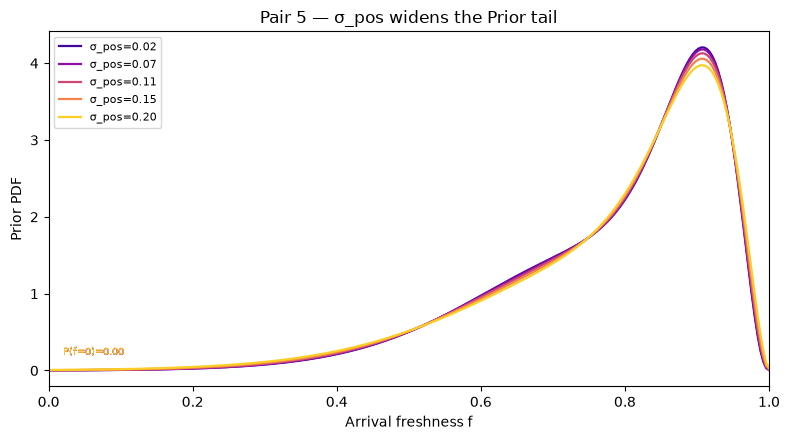

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sigmas = np.linspace(0.02, 0.20, 5)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(sigmas)))

for sig, c in zip(sigmas, colors, strict=True):
    f, pdf, p0 = marginal_pdf("prior", overrides={"sigma_pos": float(sig)})
    ax.plot(f, pdf, color=c, lw=1.6, label=f"σ_pos={sig:.2f}")
    ax.annotate(f"P(f=0)={p0:.2f}", xy=(0.02, pdf[1] + 0.2), fontsize=7, color=c)

ax.set_xlabel("Arrival freshness f")
ax.set_ylabel("Prior PDF")
ax.set_title("Pair 5 — σ_pos widens the Prior tail")
ax.set_xlim(0, 1)
ax.legend(fontsize=8)
fig.tight_layout()
p5 = FIG_DIR / "05_sigma_pos_prior.png"
fig.savefig(p5, dpi=150)
plt.show()


## Pair 6 — Hourly noise σ_hour → clean-chain trace (ρ=0)

Slider: `sigma_hour` ∈ [0, 0.08] °C OU amplitude. Chart: `truth_transit_trace` at ρ=0 (hourly wiggle only).


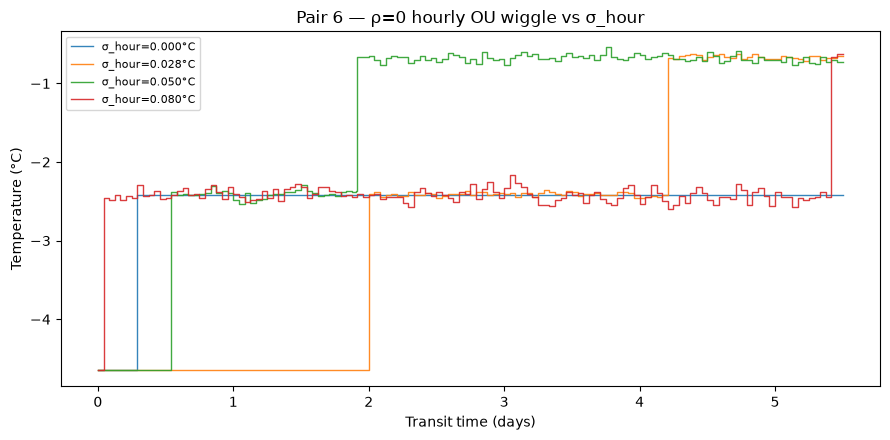

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for tr in SKETCH["sigma_hour_traces"]:
    t = np.asarray(tr["times_d"], dtype=float)
    temp = np.asarray(tr["temps_c"], dtype=float)
    ax.plot(t, temp, lw=1.0, alpha=0.9, label=f"σ_hour={tr['sigma_hour']:.3f}°C")

ax.set_xlabel("Transit time (days)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Pair 6 — ρ=0 hourly OU wiggle vs σ_hour")
ax.legend(fontsize=8)
fig.tight_layout()
p6 = FIG_DIR / "06_sigma_hour_rho_zero_trace.png"
fig.savefig(p6, dpi=150)
plt.show()
